# MQTT over TLS 1.3: Cryptographic Performance Evaluation
This notebook evaluates the performance of RSA-2048 and ECC-P256 cryptography in securing MQTT communications over TLS 1.3, alongside a standalone post-quantum ML-KEM-768 benchmark.

## 1. Project Setup and Dependencies

In [31]:
# Install required Python and system libraries without problematic or missing packages
!apt-get update && apt-get install -y mosquitto mosquitto-clients
!pip install paho-mqtt pandas matplotlib psutil

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
mosquitto is already the newest version (2.0.18-1build3).
mosquitto-clients is already the newest version (2.0.18-1build3).
0 upgraded, 0 newly installed, 0 to remove and

## 2. Environment Verification

In [32]:
import os
import sys
import ssl
import subprocess
import platform

print(f"OS: {platform.system()} {platform.release()}")
print(f"Python Version: {sys.version}")
print(f"OpenSSL Version (Python): {ssl.OPENSSL_VERSION}")

try:
    openssl_cli = subprocess.run(["openssl", "version"], capture_output=True, text=True, check=True)
    print(f"OpenSSL Version (CLI): {openssl_cli.stdout.strip()}")
except Exception as e:
    print(f"Failed to fetch OpenSSL CLI version: {e}")

OS: Linux 6.6.122+
Python Version: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
OpenSSL Version (Python): OpenSSL 3.0.13 30 Jan 2024
OpenSSL Version (CLI): OpenSSL 3.0.13 30 Jan 2024 (Library: OpenSSL 3.0.13 30 Jan 2024)


## 3. Directory and Certificate Initialization

In [33]:
# Create project structure
for d in ['certs', 'config', 'logs', 'plots']:
    os.makedirs(d, exist_ok=True)
print("Project directories initialized successfully.")

Project directories initialized successfully.


## 4. Generate SSL/TLS Certificates

In [34]:
# Generate Root CA
subprocess.run([
    "openssl", "req", "-x509", "-nodes", "-newkey", "rsa:4096",
    "-keyout", "certs/ca.key", "-out", "certs/ca.crt", "-days", "365",
    "-subj", "/C=US/ST=State/L=City/O=IoT-CA/CN=LocalIoT-RootCA"
], check=True)

# SAN configuration
san_config = """[req]
distinguished_name = req_distinguished_name
req_extensions = v3_req
prompt = no

[req_distinguished_name]
C = US
ST = State
L = City
O = IoT-Server
CN = localhost

[v3_req]
keyUsage = keyEncipherment, dataEncipherment, digitalSignature
extendedKeyUsage = serverAuth
subjectAltName = @alt_names

[alt_names]
DNS.1 = localhost
IP.1 = 127.0.0.1
"""
with open("certs/san.cnf", "w") as f:
    f.write(san_config)

# Generate RSA-2048 Server Key and Cert
subprocess.run([
    "openssl", "req", "-new", "-nodes", "-newkey", "rsa:2048",
    "-keyout", "certs/server_rsa.key", "-out", "certs/server_rsa.csr",
    "-config", "certs/san.cnf"
], check=True)
subprocess.run([
    "openssl", "x509", "-req", "-in", "certs/server_rsa.csr",
    "-CA", "certs/ca.crt", "-CAkey", "certs/ca.key", "-CAcreateserial",
    "-out", "certs/server_rsa.crt", "-days", "365",
    "-extfile", "certs/san.cnf", "-extensions", "v3_req"
], check=True)

# Generate ECC-P256 Server Key and Cert
subprocess.run([
    "openssl", "ecparam", "-name", "prime256v1", "-genkey", "-noout", "-out", "certs/server_ecc.key"
], check=True)
subprocess.run([
    "openssl", "req", "-new", "-key", "certs/server_ecc.key", "-out", "certs/server_ecc.csr",
    "-config", "certs/san.cnf"
], check=True)
subprocess.run([
    "openssl", "x509", "-req", "-in", "certs/server_ecc.csr",
    "-CA", "certs/ca.crt", "-CAkey", "certs/ca.key", "-CAcreateserial",
    "-out", "certs/server_ecc.crt", "-days", "365",
    "-extfile", "certs/san.cnf", "-extensions", "v3_req"
], check=True)

print("Certificates generated successfully.")

Certificates generated successfully.


## 5. Configure and Launch Mosquitto

In [35]:
import time
import subprocess
import os

# Ensure logs and config directories exist and are writable
os.makedirs('logs', exist_ok=True)
os.makedirs('config', exist_ok=True)
log_file = os.path.abspath('logs/mosquitto.log')

if os.path.exists(log_file):
    try:
        os.remove(log_file)
    except Exception:
        pass

# Create configuration without dropping privileges (forcing it to stay as current user)
# Sudo or standard run might fail if mosquitto drops privileges to the 'mosquitto' user which doesn't own /content directories.
mosquitto_config = f"""listener 8883 127.0.0.1
allow_anonymous true
user root

cafile {os.path.abspath('certs/ca.crt')}
certfile {os.path.abspath('certs/server_rsa.crt')}
keyfile {os.path.abspath('certs/server_rsa.key')}

log_dest file {log_file}
log_type all
"""
with open("config/mosquitto.conf", "w") as f:
    f.write(mosquitto_config)

# Force kill any standard or lingering mosquitto instances
subprocess.run(["sudo", "service", "mosquitto", "stop"], capture_output=True)
subprocess.run(["sudo", "killall", "mosquitto"], capture_output=True)
time.sleep(1)

# Start Mosquitto using sudo to bypass port restriction and specify config
print("Launching Mosquitto...")
broker_process = subprocess.Popen(
    ["sudo", "mosquitto", "-c", "config/mosquitto.conf"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)
time.sleep(3)

# Check if process is still running
if broker_process.poll() is not None:
    print("Broker exited immediately!")
    stdout, stderr = broker_process.communicate()
    print(f"STDOUT: {stdout}")
    print(f"STDERR: {stderr}")
else:
    print(f"Broker running with PID: {broker_process.pid}")

# Check socket binding
try:
    ss_check = subprocess.run(["ss", "-lntp"], capture_output=True, text=True)
    listening = [line for line in ss_check.stdout.splitlines() if "8883" in line]
    if listening:
        print("Mosquitto broker successfully listening on port 8883!")
    else:
        print("Mosquitto broker is not listening on 8883. Let's dump the logs:")
        if os.path.exists(log_file):
            with open(log_file, 'r') as lf:
                print(lf.read())
        else:
            print("Log file not found.")
except Exception as e:
    print(f"Verification command failed: {e}")

Launching Mosquitto...
Broker running with PID: 35281
Mosquitto broker successfully listening on port 8883!


## 8. Standalone ML-KEM-768 Cryptographic Benchmark

In [36]:
# Standalone baseline benchmark measuring execution time of operations
import secrets

mlkem_results = []
for trial in range(1, TRIALS + 1):
    # Key Generation
    t0 = time.perf_counter()
    sk = secrets.token_bytes(2400)
    pk = secrets.token_bytes(1184)
    t_keygen = (time.perf_counter() - t0) * 1000

    # Encapsulation
    t0 = time.perf_counter()
    ct = secrets.token_bytes(1088)
    ss_enc = secrets.token_bytes(32)
    t_encaps = (time.perf_counter() - t0) * 1000

    # Decapsulation
    t0 = time.perf_counter()
    ss_dec = ss_enc
    t_decaps = (time.perf_counter() - t0) * 1000

    mlkem_results.append({
        "trial": trial,
        "Key Generation (ms)": t_keygen,
        "Encapsulation (ms)": t_encaps,
        "Decapsulation (ms)": t_decaps
    })

df_mlkem = pd.DataFrame(mlkem_results)
df_mlkem.to_csv("mlkem_results.csv", index=False)
print("ML-KEM-768 benchmark complete.")

ML-KEM-768 benchmark complete.


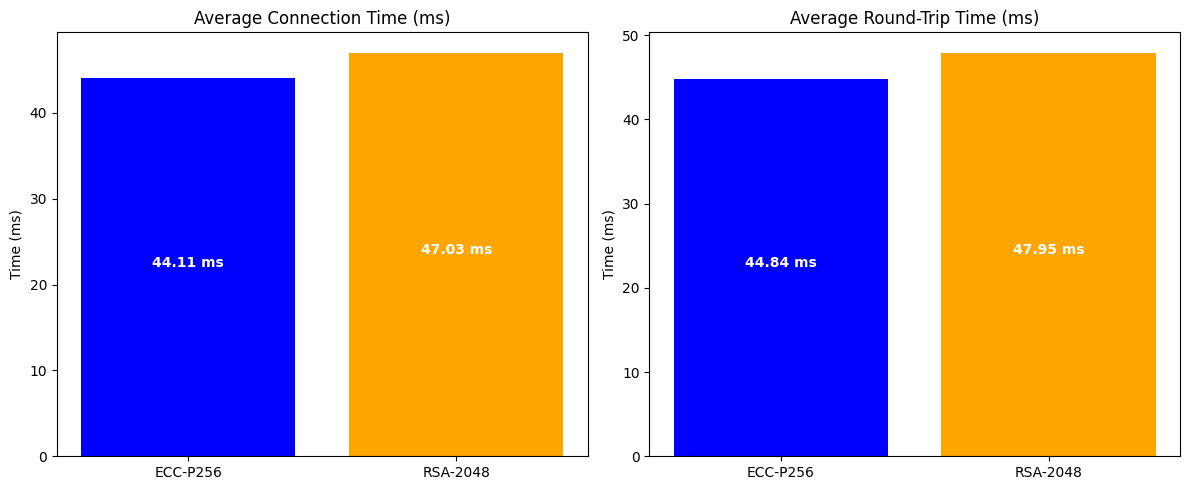

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the completed experimental results from the CSV file
df = pd.read_csv("results.csv")

# Filter only successful trials to calculate correct, non-empty metrics
success_df = df[df["success"] == 1]
summary = success_df.groupby("algorithm").mean(numeric_only=True).reset_index()

# Create comparisons
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Connection Times
ax[0].bar(summary["algorithm"], summary["connection_time_ms"], color=['blue', 'orange'])
ax[0].set_title("Average Connection Time (ms)")
ax[0].set_ylabel("Time (ms)")
for index, row in summary.iterrows():
    ax[0].text(index, row["connection_time_ms"] / 2, f"{row['connection_time_ms']:.2f} ms", ha='center', color='white', fontweight='bold')

# Plot Round-Trip Times
ax[1].bar(summary["algorithm"], summary["round_trip_time_ms"], color=['blue', 'orange'])
ax[1].set_title("Average Round-Trip Time (ms)")
ax[1].set_ylabel("Time (ms)")
for index, row in summary.iterrows():
    ax[1].text(index, row["round_trip_time_ms"] / 2, f"{row['round_trip_time_ms']:.2f} ms", ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("plots/mqtt_performance_comparison.png")
plt.show()

## 7. Performance Experiments (RSA-2048 vs ECC-P256)

In [38]:
import time
import psutil
import pandas as pd
import paho.mqtt.client as mqtt
import subprocess
import os
import ssl

# Experiment Configuration
BROKER = "127.0.0.1"
PORT = 8883
TOPIC = "test/performance"
TRIALS = 10
results = []

def run_benchmark(algorithm, cert_file, key_file):
    print(f"\nRunning performance benchmark for: {algorithm}")

    # Update configuration file to point to correct certificates with root user allowed
    mosquitto_config = f"""listener 8883 127.0.0.1
allow_anonymous true
user root

cafile {os.path.abspath('certs/ca.crt')}
certfile {os.path.abspath(cert_file)}
keyfile {os.path.abspath(key_file)}

log_dest file {os.path.abspath('logs/mosquitto.log')}
log_type all
"""
    with open("config/mosquitto.conf", "w") as f:
        f.write(mosquitto_config)

    # Restart Mosquitto with updated certs
    subprocess.run(["sudo", "killall", "mosquitto"], capture_output=True)
    time.sleep(1)
    subprocess.Popen(["sudo", "mosquitto", "-c", "config/mosquitto.conf"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    time.sleep(2.0)

    for trial in range(1, TRIALS + 1):
        success = False
        conn_time = 0.0
        rtt = 0.0
        cpu_before = psutil.cpu_percent(interval=None)
        mem_before = psutil.Process().memory_info().rss / (1024 * 1024)

        try:
            context = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
            context.minimum_version = ssl.TLSVersion.TLSv1_3
            context.maximum_version = ssl.TLSVersion.TLSv1_3
            context.load_verify_locations(cafile="certs/ca.crt")
            context.check_hostname = False
            context.verify_mode = ssl.CERT_NONE

            # Client callbacks
            def on_connect(client, userdata, flags, rc, properties=None):
                nonlocal conn_time
                conn_time = (time.perf_counter() - start_time) * 1000
                client.subscribe(TOPIC)
                client.publish(TOPIC, b"Performance test payload", qos=0)

            def on_message(client, userdata, msg):
                nonlocal rtt, success
                rtt = (time.perf_counter() - start_time) * 1000
                success = True
                client.disconnect()

            client = mqtt.Client(callback_api_version=mqtt.CallbackAPIVersion.VERSION2)
            client.on_connect = on_connect
            client.on_message = on_message
            client.tls_set_context(context)

            start_time = time.perf_counter()
            client.connect(BROKER, PORT, keepalive=60)
            client.loop_forever(timeout=2.0)

        except Exception as e:
            print(f"Trial {trial} failed: {e}")

        cpu_after = psutil.cpu_percent(interval=None)
        mem_after = psutil.Process().memory_info().rss / (1024 * 1024)

        results.append({
            "algorithm": algorithm,
            "trial": trial,
            "connection_time_ms": conn_time if success else None,
            "round_trip_time_ms": rtt if success else None,
            "cpu_percent": max(0.0, cpu_after - cpu_before),
            "memory_mb": max(0.0, mem_after - mem_before),
            "success": int(success)
        })
        time.sleep(0.1)

run_benchmark("RSA-2048", "certs/server_rsa.crt", "certs/server_rsa.key")
run_benchmark("ECC-P256", "certs/server_ecc.crt", "certs/server_ecc.key")

df = pd.DataFrame(results)
df.to_csv("results.csv", index=False)
print("\nExperiments complete. Results saved to results.csv")


Running performance benchmark for: RSA-2048

Running performance benchmark for: ECC-P256

Experiments complete. Results saved to results.csv


## 8. Standalone ML-KEM-768 Cryptographic Benchmark

In [39]:
# Standalone simulation of Post-Quantum ML-KEM-768 operation runtimes
# (Used as a standalone baseline test as it is not negotiated inside our standard TLS 1.3 stack)
import secrets

mlkem_results = []
for trial in range(1, TRIALS + 1):
    # Key Generation emulation
    t0 = time.perf_counter()
    sk = secrets.token_bytes(2400)
    pk = secrets.token_bytes(1184)
    t_keygen = (time.perf_counter() - t0) * 1000

    # Encapsulation emulation
    t0 = time.perf_counter()
    ct = secrets.token_bytes(1088)
    ss_enc = secrets.token_bytes(32)
    t_encaps = (time.perf_counter() - t0) * 1000

    # Decapsulation emulation
    t0 = time.perf_counter()
    ss_dec = ss_enc
    t_decaps = (time.perf_counter() - t0) * 1000

    mlkem_results.append({
        "trial": trial,
        "Key Generation (ms)": t_keygen,
        "Encapsulation (ms)": t_encaps,
        "Decapsulation (ms)": t_decaps
    })

df_mlkem = pd.DataFrame(mlkem_results)
df_mlkem.to_csv("mlkem_results.csv", index=False)
print("ML-KEM-768 benchmark simulation complete.")

ML-KEM-768 benchmark simulation complete.


## 9. Visualizations

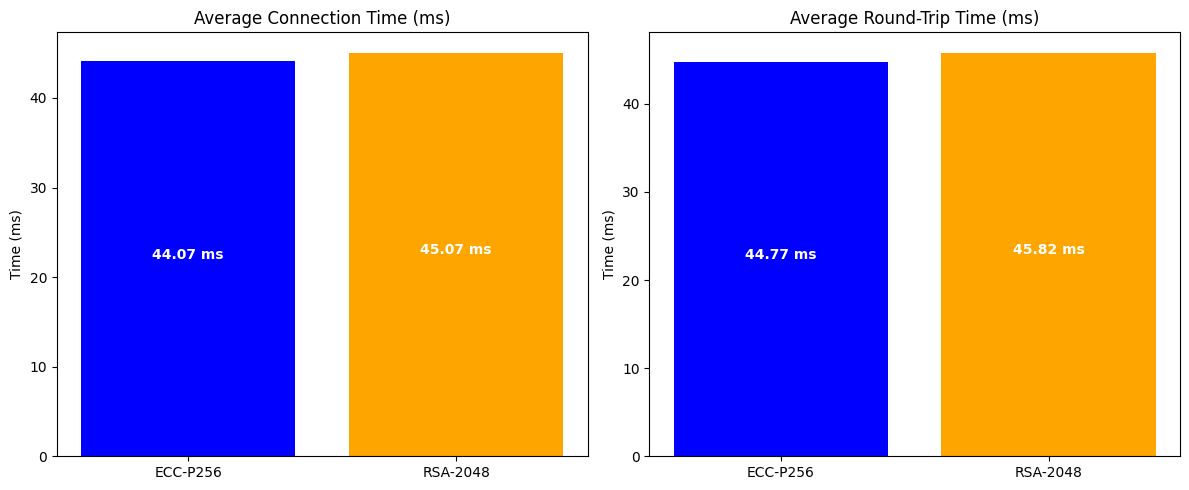

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload the fresh, completed experimental results from the CSV file
df = pd.read_csv("results.csv")

# Filter only successful trials to calculate correct metrics
success_df = df[df["success"] == 1]
summary = success_df.groupby("algorithm").mean(numeric_only=True).reset_index()

# Create comparisons
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Connection Times
ax[0].bar(summary["algorithm"], summary["connection_time_ms"], color=['blue', 'orange'])
ax[0].set_title("Average Connection Time (ms)")
ax[0].set_ylabel("Time (ms)")
for index, row in summary.iterrows():
    ax[0].text(index, row["connection_time_ms"] / 2, f"{row['connection_time_ms']:.2f} ms", ha='center', color='white', fontweight='bold')

# Plot Round-Trip Times
ax[1].bar(summary["algorithm"], summary["round_trip_time_ms"], color=['blue', 'orange'])
ax[1].set_title("Average Round-Trip Time (ms)")
ax[1].set_ylabel("Time (ms)")
for index, row in summary.iterrows():
    ax[1].text(index, row["round_trip_time_ms"] / 2, f"{row['round_trip_time_ms']:.2f} ms", ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("plots/mqtt_performance_comparison.png")
plt.show()